# Extração de Dados Financeiros por Setor

## Objetivo

Este notebook automatiza a extração e organização de dados financeiros de empresas listadas na B3, agrupados por setor econômico. Para cada empresa, são extraídas cinco métricas do balanço patrimonial e da demonstração de resultados em série temporal trimestral:

| Coluna | Descrição |
|---|---|
| `receita_liquida` | Receita líquida |
| `custo` | Custo dos bens e/ou serviços vendidos |
| `contas_receber` | Contas a receber |
| `estoques` | Estoques |
| `fornecedores` | Fornecedores |

O resultado final é um painel de dados (*panel data*): **uma linha por empresa por data**.

## Fonte dos dados

Os dados foram extraídos do **ComDinheiro by Nelogica** (seção RI), plataforma de informações financeiras disponível em [https://comdinheiro.com.br](https://comdinheiro.com.br).

---

**Autor:** Vinícius Argolo Coimbra <br>
**Data:** 26/06/2026

## 1. Importações

In [85]:
import os            # navegação em diretórios e caminhos de arquivo
import pandas as pd  # manipulação e análise de dados tabulares
import openpyxl      # motor para leitura e escrita de arquivos .xlsx

## 2. Configurações

In [86]:
# Os caminhos são relativos à localização do notebook, tornando-o portátil
# entre máquinas desde que a estrutura de pastas seja preservada.

# Detecta a pasta base: usa __file__ em scripts, getcwd() no Jupyter
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

# Pasta raiz contendo as subpastas por setor (mesma pasta do notebook)
pasta_dados = BASE_DIR

# Pasta de destino para o arquivo Excel de saída
pasta_saida = os.path.join(BASE_DIR, "Extração", "Tabelas")
os.makedirs(pasta_saida, exist_ok=True)

## 3. Leitura dos arquivos por setor

Para cada subpasta de setor, o notebook percorre todos os arquivos `.xlsx` encontrados. Cada arquivo corresponde a uma empresa, identificada pelo nome do arquivo (ticker). O script extrai quatro indicadores do balanço patrimonial pelo rótulo exato da linha no Excel e organiza os dados no formato de painel: **uma linha por empresa por data**.

Caso um indicador não seja encontrado em determinado arquivo, a coluna é preenchida com `NaN` e um aviso é exibido — o processamento dos demais arquivos continua normalmente.

In [87]:
# Rótulos exatos das linhas de indicadores conforme aparecem no arquivo Excel
LABELS = {
    "receita_liquida" : "  Receita Líquida",
    "custo"           : "    Custo dos Bens e/ou Serviços Vendidos",
    "contas_receber"  : "    Contas a Receber",
    "estoques"        : "    Estoques",
    "fornecedores"    : "    Fornecedores",
    "dividas_de_cp"   : "    Empréstimos e Financiamentos CP",  # Coluna adicionada: dividas_de_cp
}

lista_dataframes = []

# Percorre cada subpasta (setor) dentro da pasta de dados
for setor in sorted(os.listdir(pasta_dados)):
    caminho_setor = os.path.join(pasta_dados, setor)

    if not os.path.isdir(caminho_setor):
        continue

    # Percorre cada arquivo Excel dentro da pasta do setor
    for arquivo in sorted(os.listdir(caminho_setor)):
        if not arquivo.endswith(".xlsx"):
            continue

        caminho_arquivo = os.path.join(caminho_setor, arquivo)
        ticker = os.path.splitext(arquivo)[0]

        # Lê o arquivo bruto: indicadores nas linhas, datas nas colunas
        try:
            df_raw = pd.read_excel(
                caminho_arquivo,
                sheet_name="comdinheiro",
                index_col=0,
                header=0
            )
        except Exception as erro:
            print(f"AVISO: não foi possível ler {arquivo} ({setor}) — {erro}")
            continue

        # Extrai cada indicador pelo rótulo exato; preenche com NaN se ausente
        dados = {}
        for coluna, rotulo in LABELS.items():
            if rotulo in df_raw.index:
                dados[coluna] = df_raw.loc[rotulo]
            else:
                print(f"AVISO: '{coluna}' não encontrado em {arquivo}")
                dados[coluna] = pd.Series(dtype=float, index=df_raw.columns)

        # Converte para o formato longo: uma linha por empresa por data
        df_empresa = pd.DataFrame(dados)
        df_empresa.index.name = "data"
        df_empresa = df_empresa.reset_index()
        df_empresa["ticker"] = ticker
        df_empresa["setor"] = setor

        lista_dataframes.append(df_empresa)

print(f"Total de arquivos processados com sucesso: {len(lista_dataframes)}")

Total de arquivos processados com sucesso: 24


## 4. Consolidação dos dados

In [88]:
# Concatena todos os DataFrames individuais em um único painel
df_master = pd.concat(lista_dataframes, ignore_index=True)

# Reordena as colunas na sequência exata definida pelo projeto
COLUNAS_FINAIS = ["data", "setor", "ticker", "receita_liquida", "custo", "contas_receber", "estoques", "fornecedores", "dividas_de_cp"]
df_master = df_master[COLUNAS_FINAIS]

# Custo vem negativo na fonte; converte para valor absoluto
df_master["custo"] = df_master["custo"].abs()

# Prévia dos primeiros registros e dimensões totais
print(f"Dimensões do painel: {df_master.shape[0]} linhas × {df_master.shape[1]} colunas")
df_master.head()

Dimensões do painel: 1447 linhas × 9 colunas


,data,setor,ticker,receita_liquida,custo,contas_receber,estoques,fornecedores,dividas_de_cp
0,31/12/2010,A&B,ABEV3,NaN,NaN,NaN,NaN,NaN,NaN
1,31/03/2011,A&B,ABEV3,NaN,NaN,NaN,NaN,NaN,NaN
2,30/06/2011,A&B,ABEV3,NaN,NaN,NaN,NaN,NaN,NaN
3,30/09/2011,A&B,ABEV3,NaN,NaN,NaN,NaN,NaN,NaN
4,31/12/2011,A&B,ABEV3,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Verificação de qualidade

Antes de exportar, é importante confirmar que os dados foram lidos corretamente. Esta etapa verifica:

- **Cobertura**: total de linhas e tickers únicos no painel
- **Período**: datas mais antiga e mais recente presentes nos dados
- **Completude**: quantidade de valores ausentes por coluna

Valores ausentes expressivos em uma coluna podem indicar falha na leitura ou a ausência daquele indicador para determinadas empresas — situação esperada em alguns casos.

In [89]:
# Cobertura: total de linhas e tickers únicos
print(f"Total de linhas no painel: {len(df_master)}")
print(f"Tickers únicos: {df_master['ticker'].nunique()}")
print(sorted(df_master['ticker'].unique()))

# Converte a coluna de datas para datetime e formata como dd/mm/yyyy
datas_dt = pd.to_datetime(df_master["data"], format="%d/%m/%Y", errors="coerce")
df_master["data"] = datas_dt.dt.strftime("%d/%m/%Y")

# Intervalo temporal dos dados
print(f"\nData mínima: {datas_dt.min().strftime('%Y-%m-%d')}")
print(f"Data máxima: {datas_dt.max().strftime('%Y-%m-%d')}")

# Detecta falhas de conversão (datas que não puderam ser interpretadas)
datas_invalidas = datas_dt.isna().sum()
print(f"Datas não reconhecidas (NaT): {datas_invalidas}")

# Diagnóstico de valores ausentes por coluna
print("\nValores ausentes por coluna:")
print(df_master.isnull().sum().to_string())

Total de linhas no painel: 1447
Tickers únicos: 24
['AALR3', 'ABEV3', 'AGRO3', 'ASAI3', 'BHIA3', 'BRFS3', 'CAML3', 'CEAB3', 'CRFB3', 'FLRY3', 'GMAT3', 'HAPV3', 'JBSS3', 'LAND3', 'LREN3', 'MATD3', 'MDIA3', 'MGLU3', 'MRFG3', 'PETZ3', 'RDOR3', 'SLCE3', 'SMTO3', 'SOJA3']

Data mínima: 2010-12-31
Data máxima: 2026-03-31
Datas não reconhecidas (NaT): 0

Valores ausentes por coluna:
data                 0
setor                0
ticker               0
receita_liquida    430
custo              430
contas_receber     416
estoques           462
fornecedores       463
dividas_de_cp      465


In [90]:
# Arquivo original salvo antes de qualquer remoção de linhas ou cálculo
caminho_originais = os.path.join(pasta_saida, "dados_originais.xlsx")
df_master.to_excel(caminho_originais, index=False)
print(f"Arquivo original salvo: {df_master.shape[0]} linhas × {df_master.shape[1]} colunas")
print(f"  → {caminho_originais}")

# Linhas com campos em branco removidas apenas do df tratado — original preservado
COLUNAS_BASE = ["contas_receber", "receita_liquida", "fornecedores", "custo", "estoques", "dividas_de_cp"]
df_tratado = df_master.dropna(subset=COLUNAS_BASE).reset_index(drop=True)

linhas_removidas = len(df_master) - len(df_tratado)
print(f"\nLinhas removidas (pelo menos um campo em branco): {linhas_removidas}")
print(f"Linhas restantes no df_tratado: {len(df_tratado)}")

Arquivo original salvo: 1447 linhas × 9 colunas
  → /Users/viniciuscoimbra/Desktop/Trabalho_Vinicius/Extração/Tabelas/dados_originais.xlsx

Linhas removidas (pelo menos um campo em branco): 481
Linhas restantes no df_tratado: 966


## 6.5 Enriquecimento com Selic

Incorpora a taxa Selic meta (% a.a.) ao painel tratado, via *left join* pela data exata (`dd/mm/aaaa`). A série temporal diária foi obtida do Copom e está armazenada localmente em `Extração/Tabelas/STI-20260607220158990.csv`.

In [91]:
# Lê o CSV da Selic — separador ponto-e-vírgula
caminho_selic = os.path.join(pasta_saida, "STI-20260607220158990.csv")
df_selic = pd.read_csv(caminho_selic, encoding="utf-8-sig", sep=";")

# Remove a linha de rodapé "Source;Copom" — mantém apenas datas no formato dd/mm/aaaa
df_selic = df_selic[df_selic["Date"].str.match(r"\d{2}/\d{2}/\d{4}", na=False)].copy()

# Renomeia colunas para nomes curtos e converte o valor para numérico
df_selic = df_selic.rename(columns={"Date": "data_selic", df_selic.columns[1]: "selic"})
df_selic["selic"] = pd.to_numeric(df_selic["selic"], errors="coerce")

# Left join pela data exata — o formato dd/mm/aaaa é idêntico nos dois DataFrames
df_tratado = df_tratado.merge(df_selic, left_on="data", right_on="data_selic", how="left")
df_tratado = df_tratado.drop(columns=["data_selic"])

# Validação
nao_nulos = df_tratado["selic"].notna().sum()
print(f"Coluna 'selic' adicionada: {nao_nulos} de {len(df_tratado)} linhas com valor correspondido")

Coluna 'selic' adicionada: 959 de 966 linhas com valor correspondido


## 7. Colunas calculadas

Indicadores de gestão de capital de giro calculados a partir dos dados extraídos. Cada coluna é adicionada ao painel existente sem remover ou renomear nenhuma coluna anterior.

In [92]:
# Colunas calculadas — adicionadas após extração e conversão de tipos

# Ordenação necessária para cálculos de variação por ticker
df_tratado["_data_dt"] = pd.to_datetime(df_tratado["data"], format="%d/%m/%Y", errors="coerce")
df_tratado = df_tratado.sort_values(["ticker", "_data_dt"]).drop(columns=["_data_dt"]).reset_index(drop=True)

# Prazo médio de recebimento em dias
# Denominador zero tratado como NaN para evitar infinito
df_tratado["dias_a_receber"] = (
    df_tratado["contas_receber"] / df_tratado["receita_liquida"].replace(0, float("nan")) * 90
)

# Prazo médio de pagamento em dias
# Denominador zero tratado como NaN para evitar infinito
df_tratado["dias_a_pagar"] = (
    df_tratado["fornecedores"] / df_tratado["custo"].replace(0, float("nan")) * 90
)

# Prazo médio de estoque em dias
# Denominador zero tratado como NaN para evitar infinito
df_tratado["dias_com_estoque"] = (
    df_tratado["estoques"] / df_tratado["custo"].replace(0, float("nan")) * 90
)

# Ciclo financeiro em dias
df_tratado["ciclo_financeiro"] = (
    df_tratado["dias_com_estoque"] + df_tratado["dias_a_receber"] - df_tratado["dias_a_pagar"]
)

# Necessidade de capital de giro
df_tratado["ncg"] = df_tratado["estoques"] + df_tratado["contas_receber"] - df_tratado["fornecedores"]

# NCG como proporção da receita líquida — resultado em percentual (%)
# Denominador zero tratado como NaN para evitar infinito
df_tratado["ncg_sobre_receita"] = (
    df_tratado["ncg"] / df_tratado["receita_liquida"].replace(0, float("nan")) * 100
)

# Variação da NCG em relação ao período anterior
# Primeiro período de cada ticker resulta em NaN — esperado
df_tratado["var_ncg"] = df_tratado.groupby("ticker")["ncg"].diff(1)

# Variação das dívidas de CP em relação ao período anterior
# Primeiro período de cada ticker resulta em NaN — esperado
df_tratado["var_dividas_de_cp"] = df_tratado.groupby("ticker")["dividas_de_cp"].diff(1)

# Proporção da variação das dívidas CP sobre a variação da NCG — resultado em percentual (%)
# Denominador zero tratado como NaN para evitar infinito
df_tratado["var_dividas_sobre_var_ncg"] = (
    df_tratado["var_dividas_de_cp"] / df_tratado["var_ncg"].replace(0, float("nan")) * 100
)

# Validação rápida: colunas calculadas e contagem de valores não nulos
colunas_calculadas = [
    "dias_a_receber", "dias_a_pagar", "dias_com_estoque", "ciclo_financeiro",
    "ncg", "ncg_sobre_receita", "var_ncg", "var_dividas_de_cp", "var_dividas_sobre_var_ncg",
]
print("Colunas calculadas adicionadas:")
for col in colunas_calculadas:
    nao_nulos = df_tratado[col].notna().sum()
    print(f"  {col}: {nao_nulos} valores não nulos de {len(df_tratado)}")

Colunas calculadas adicionadas:
  dias_a_receber: 964 valores não nulos de 966
  dias_a_pagar: 964 valores não nulos de 966
  dias_com_estoque: 964 valores não nulos de 966
  ciclo_financeiro: 964 valores não nulos de 966
  ncg: 966 valores não nulos de 966
  ncg_sobre_receita: 964 valores não nulos de 966
  var_ncg: 943 valores não nulos de 966
  var_dividas_de_cp: 943 valores não nulos de 966
  var_dividas_sobre_var_ncg: 942 valores não nulos de 966


In [93]:
# Arquivo tratado salvo após remoção de incompletos e cálculo das colunas adicionais
caminho_tratados = os.path.join(pasta_saida, "dados_tratados.xlsx")
df_tratado.to_excel(caminho_tratados, index=False)
print(f"Arquivo tratado salvo: {df_tratado.shape[0]} linhas × {df_tratado.shape[1]} colunas")
print(f"  → {caminho_tratados}")

Arquivo tratado salvo: 966 linhas × 19 colunas
  → /Users/viniciuscoimbra/Desktop/Trabalho_Vinicius/Extração/Tabelas/dados_tratados.xlsx


## 6. Exportação por setor

In [94]:
# Define o caminho completo do arquivo de saída
nome_arquivo = "dados_financeiros_por_setor.xlsx"
caminho_arquivo_saida = os.path.join(pasta_saida, nome_arquivo)

# Agrupa por setor e salva cada grupo em uma aba separada do mesmo arquivo
abas_criadas = []

with pd.ExcelWriter(caminho_arquivo_saida, engine="openpyxl") as writer:
    for setor, df_setor in df_master.groupby("setor"):
        df_setor.to_excel(writer, sheet_name=setor, index=False)
        abas_criadas.append(setor)

# Confirma o resultado da exportação
print(f"Arquivo salvo em:\n  {caminho_arquivo_saida}\n")
print(f"Abas criadas ({len(abas_criadas)}):")
for aba in abas_criadas:
    print(f"  → {aba}")

Arquivo salvo em:
  /Users/viniciuscoimbra/Desktop/Trabalho_Vinicius/Extração/Tabelas/dados_financeiros_por_setor.xlsx

Abas criadas (4):
  → A&B
  → Agro
  → Saúde
  → Varejo


In [95]:
!pip install matplotlib

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import unicodedata

# Trabalha numa cópia para não alterar df_tratado
dfg = df_tratado.copy()
dfg["data_dt"] = pd.to_datetime(dfg["data"], format="%d/%m/%Y", errors="coerce")
dfg = dfg.sort_values("data_dt")

# Normaliza o nome do setor para evitar problema com o acento de "Saúde"
dfg["setor"] = dfg["setor"].map(lambda s: unicodedata.normalize("NFC", str(s)))
SETORES = list(dfg["setor"].unique())   # pega os nomes reais da base

# Paleta fixa por setor (mesma do TCC)
CORES = {"A&B": "#2E5E4E", "Agro": "#C28B2B", "Saúde": "#3D5A80", "Varejo": "#9B3A3A"}

# Pasta para salvar as figuras (na mesma pasta de saída do projeto)
pasta_graficos = os.path.join(pasta_saida, "Graficos")
os.makedirs(pasta_graficos, exist_ok=True)

plt.rcParams.update({"font.size": 11})
print("Setup pronto. Setores:", SETORES)


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Setup pronto. Setores: ['Agro', 'A&B', 'Varejo', 'Saúde']


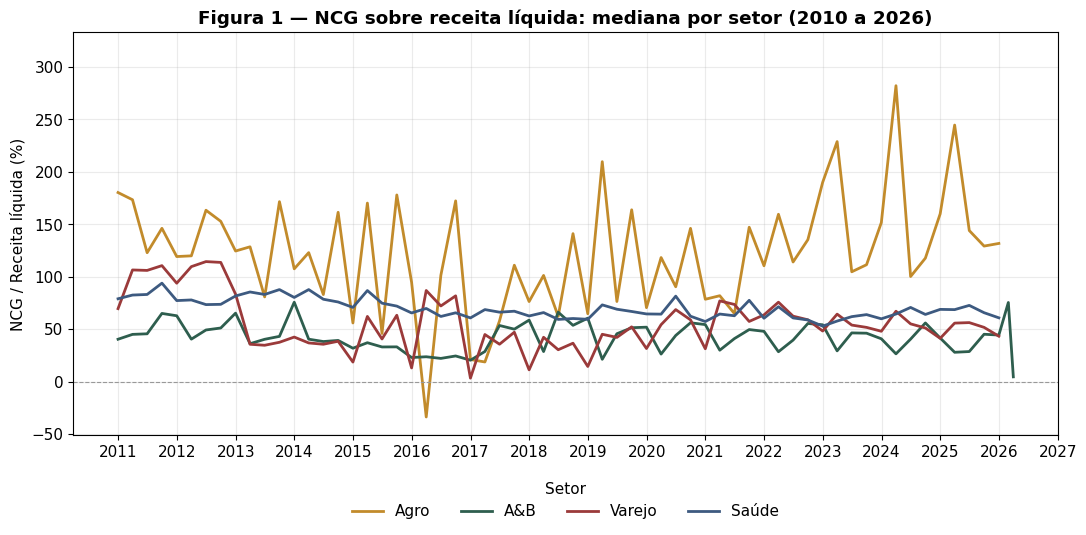

In [96]:
# FIGURA 1 — NCG sobre receita: mediana por setor ao longo do tempo
# Usa mediana (não média) porque há empresas com valores extremos que
# distorceriam a média; a mediana é robusta a esses outliers.
g1 = dfg.groupby(["data_dt", "setor"])["ncg_sobre_receita"].median().unstack()

fig, ax = plt.subplots(figsize=(11, 5.5))
for s in SETORES:
    ax.plot(g1.index, g1[s], label=s, color=CORES.get(s), lw=2)
ax.axhline(0, color="#999", lw=0.8, ls="--")
ax.set_title("Figura 1 — NCG sobre receita líquida: mediana por setor (2010 a 2026)",
             fontweight="bold")
ax.set_ylabel("NCG / Receita líquida (%)")
ax.legend(title="Setor", frameon=False, ncol=4,
          loc="upper center", bbox_to_anchor=(0.5, -0.08))
ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(os.path.join(pasta_graficos, "fig1_ncg_setor.png"), dpi=160, bbox_inches="tight")
plt.show()

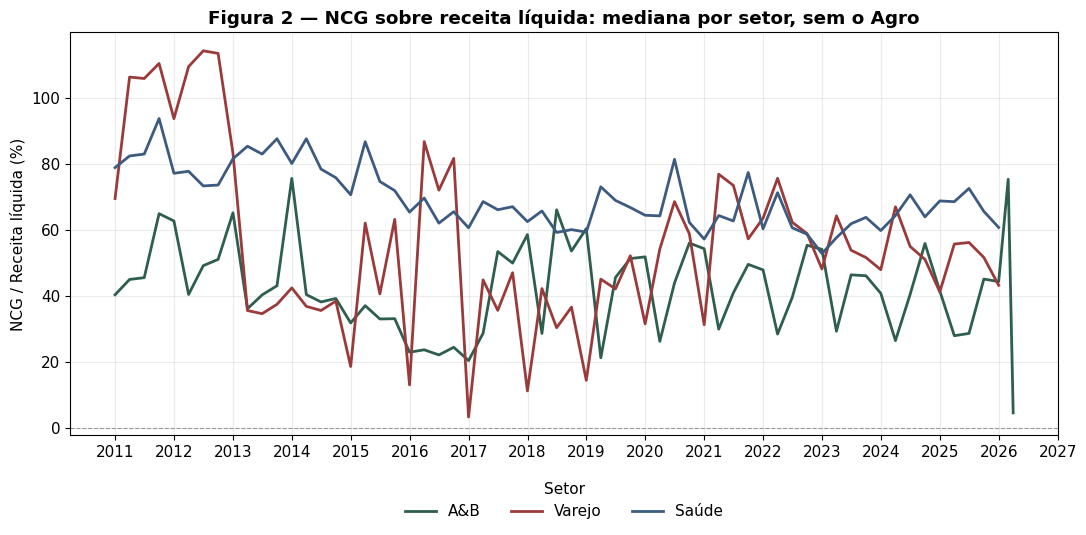

In [97]:
# FIGURA 2 — Mesmo gráfico da Figura 1, mas sem o Agro.
# O Agro opera em patamar muito alto e achata os outros três; removê-lo
# deixa visível a variação de A&B, Saúde e Varejo.
fig, ax = plt.subplots(figsize=(11, 5.5))
for s in [x for x in SETORES if x != "Agro"]:
    ax.plot(g1.index, g1[s], label=s, color=CORES.get(s), lw=2)
ax.axhline(0, color="#999", lw=0.8, ls="--")
ax.set_title("Figura 2 — NCG sobre receita líquida: mediana por setor, sem o Agro",
             fontweight="bold")
ax.set_ylabel("NCG / Receita líquida (%)")
ax.legend(title="Setor", frameon=False, ncol=3,
          loc="upper center", bbox_to_anchor=(0.5, -0.08))
ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(os.path.join(pasta_graficos, "fig2_sem_agro.png"), dpi=160, bbox_inches="tight")
plt.show()

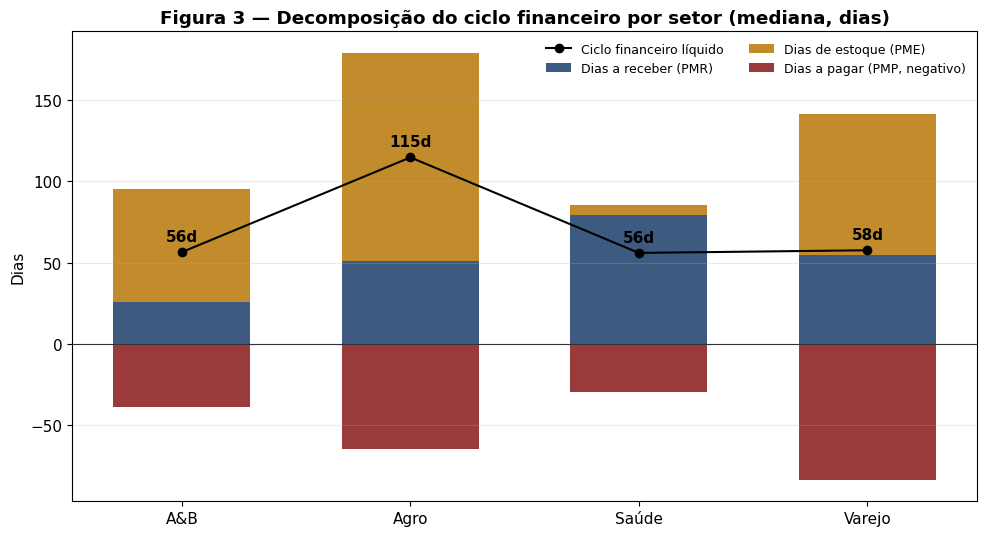

In [98]:
# FIGURA 3 — Decomposição do ciclo financeiro por setor (mediana, em dias)
# PMR (receber) e PME (estoque) são positivos e empilhados; PMP (pagar) é
# negativo porque reduz a necessidade de giro. A linha mostra o ciclo líquido.
ordem = [s for s in ["A&B", "Agro", "Saúde", "Varejo"] if s in SETORES]
comp = dfg.groupby("setor")[["dias_a_receber", "dias_com_estoque", "dias_a_pagar"]].median().reindex(ordem)

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(comp)); w = 0.6
ax.bar(x, comp["dias_a_receber"], w, label="Dias a receber (PMR)", color="#3D5A80")
ax.bar(x, comp["dias_com_estoque"], w, bottom=comp["dias_a_receber"],
       label="Dias de estoque (PME)", color="#C28B2B")
ax.bar(x, -comp["dias_a_pagar"], w, label="Dias a pagar (PMP, negativo)", color="#9B3A3A")
ciclo = comp["dias_a_receber"] + comp["dias_com_estoque"] - comp["dias_a_pagar"]
ax.plot(x, ciclo, "ko-", lw=1.5, label="Ciclo financeiro líquido")
for i, v in enumerate(ciclo):
    ax.annotate(f"{v:.0f}d", (i, v), textcoords="offset points",
                xytext=(0, 8), ha="center", fontweight="bold")
ax.axhline(0, color="#333", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(comp.index)
ax.set_title("Figura 3 — Decomposição do ciclo financeiro por setor (mediana, dias)",
             fontweight="bold")
ax.set_ylabel("Dias")
ax.legend(frameon=False, fontsize=9, ncol=2)
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(pasta_graficos, "fig3_ciclo.png"), dpi=160, bbox_inches="tight")
plt.show()

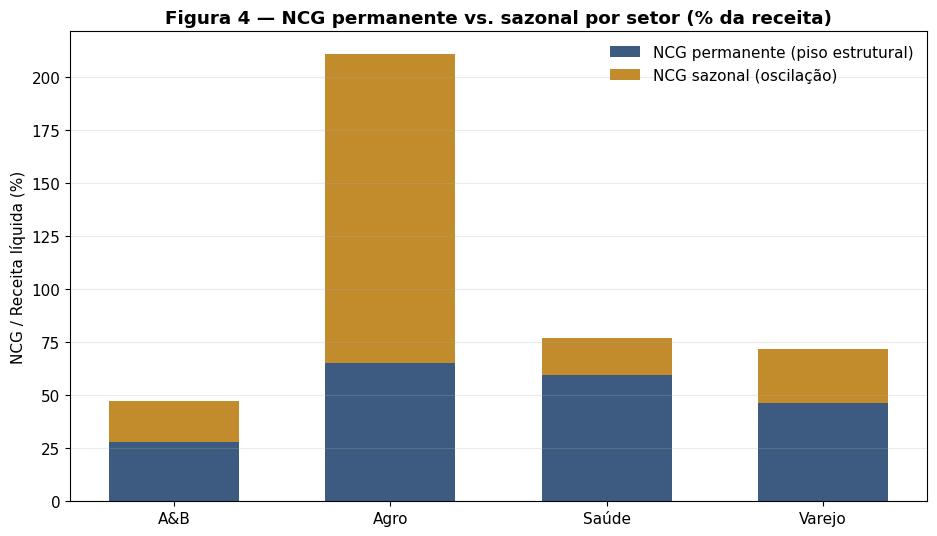

In [99]:
# FIGURA 4 — NCG permanente vs. sazonal por setor (% da receita)
# Para cada empresa: permanente = 1º quartil (piso que ela quase sempre mantém);
# sazonal = 3º quartil menos 1º quartil (amplitude interquartílica = tamanho da
# oscilação típica). Só entram empresas com pelo menos 8 trimestres. Depois
# tira-se a mediana desses valores entre as empresas do setor.
linhas = []
for s in ordem:
    sub = dfg[dfg["setor"] == s]
    perms, sazs = [], []
    for tk, gp in sub.groupby("ticker"):
        v = gp["ncg_sobre_receita"].dropna()
        if len(v) >= 8:
            q1, q3 = np.percentile(v, 25), np.percentile(v, 75)
            perms.append(q1)
            sazs.append(q3 - q1)
    linhas.append((s, np.median(perms), np.median(sazs)))

perm = pd.DataFrame(linhas, columns=["setor", "permanente", "sazonal"]).set_index("setor")

fig, ax = plt.subplots(figsize=(9.5, 5.5))
x = np.arange(len(perm))
ax.bar(x, perm["permanente"], 0.6, label="NCG permanente (piso estrutural)", color="#3D5A80")
ax.bar(x, perm["sazonal"], 0.6, bottom=perm["permanente"],
       label="NCG sazonal (oscilação)", color="#C28B2B")
ax.set_xticks(x); ax.set_xticklabels(perm.index)
ax.set_title("Figura 4 — NCG permanente vs. sazonal por setor (% da receita)",
             fontweight="bold")
ax.set_ylabel("NCG / Receita líquida (%)")
ax.legend(frameon=False)
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(pasta_graficos, "fig4_perm_sazonal.png"), dpi=160, bbox_inches="tight")
plt.show()

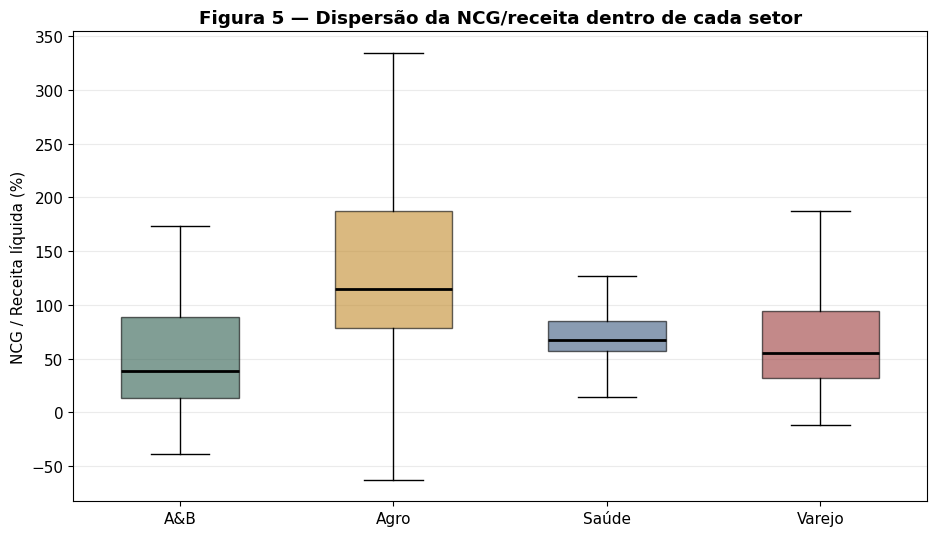

In [100]:
# FIGURA 5 — Dispersão da NCG/receita dentro de cada setor (boxplot)
# Mostra o quanto as empresas variam dentro do setor. showfliers=False esconde
# os outliers extremos só para manter a escala legível.
fig, ax = plt.subplots(figsize=(9.5, 5.5))
dados_box = [dfg[dfg["setor"] == s]["ncg_sobre_receita"].dropna().values for s in ordem]
bp = ax.boxplot(dados_box, tick_labels=ordem, patch_artist=True, showfliers=False, widths=0.55)
for patch, s in zip(bp["boxes"], ordem):
    patch.set_facecolor(CORES.get(s)); patch.set_alpha(0.6)
for med in bp["medians"]:
    med.set_color("black"); med.set_linewidth(2)
ax.set_title("Figura 5 — Dispersão da NCG/receita dentro de cada setor", fontweight="bold")
ax.set_ylabel("NCG / Receita líquida (%)")
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(pasta_graficos, "fig5_boxplot.png"), dpi=160, bbox_inches="tight")
plt.show()

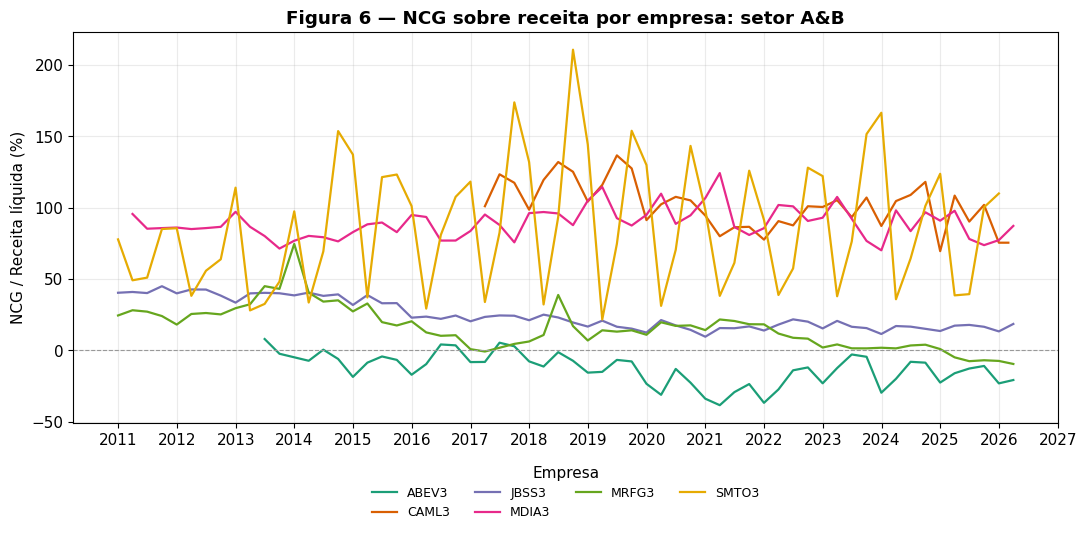

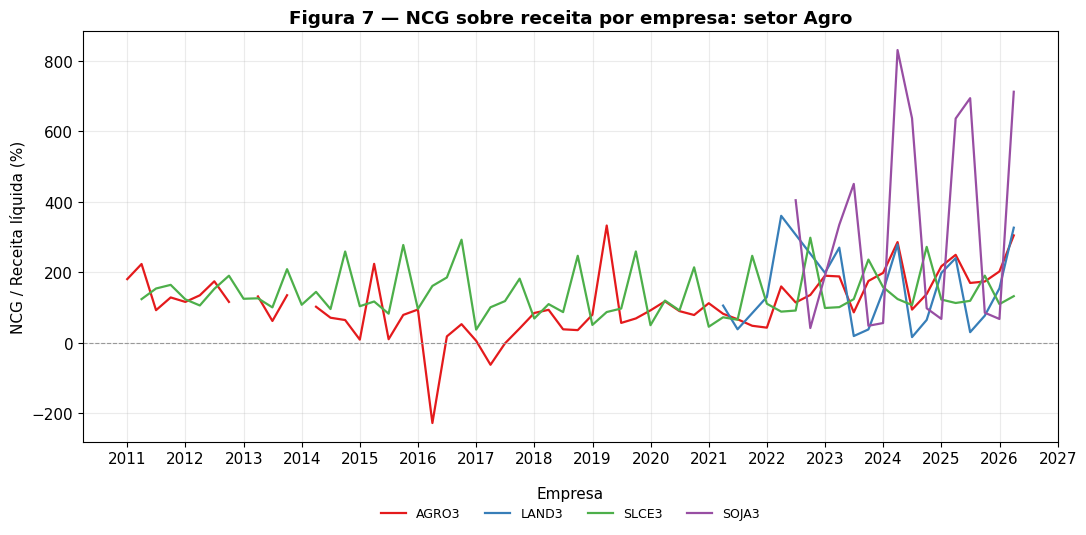

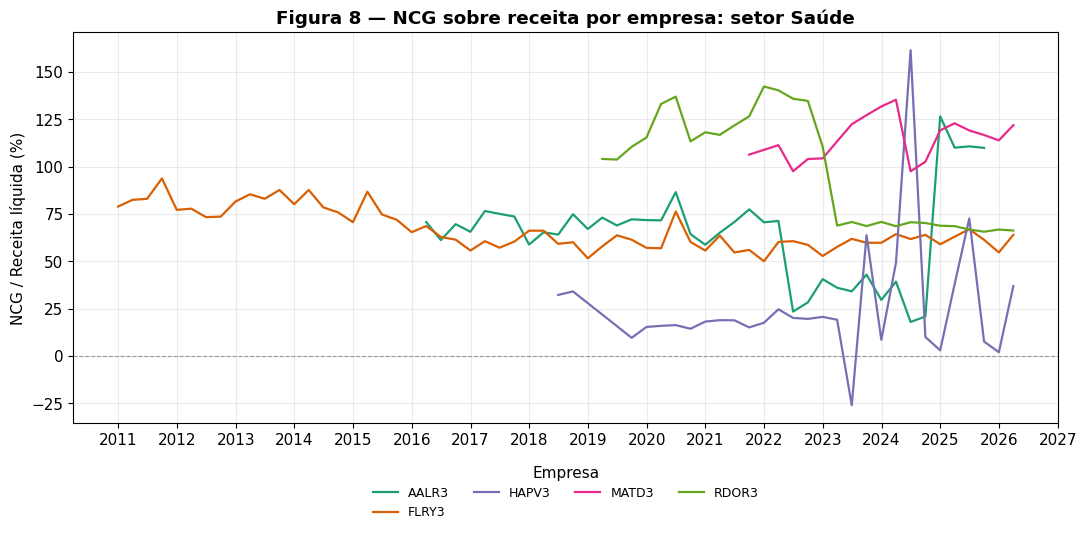

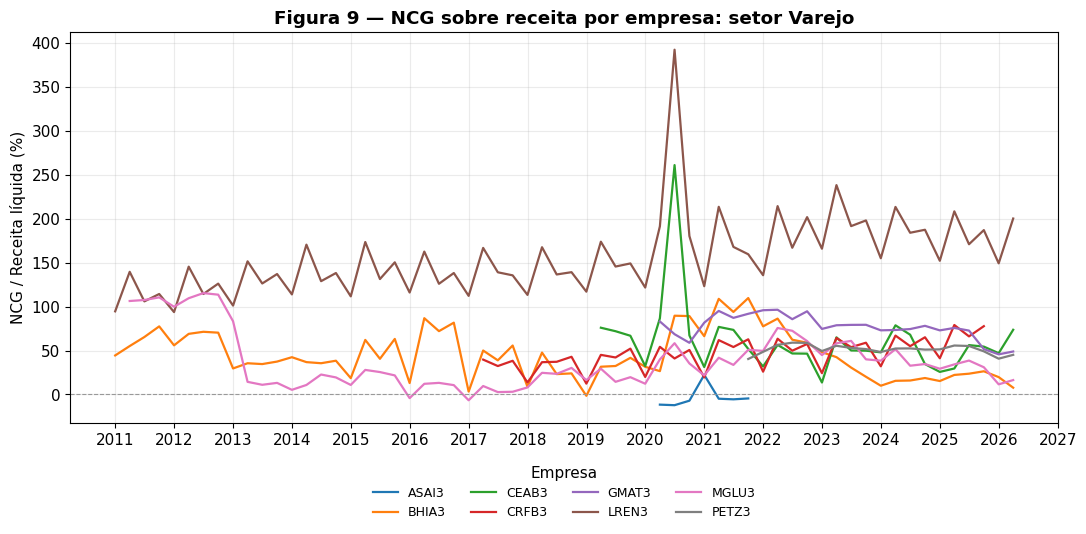

In [101]:
# FIGURAS 6 a 9 — NCG/receita por empresa, um gráfico por setor.
# Aqui NÃO se usa mediana: cada linha é uma empresa, com o dado trimestral cru.
# Mostra a diversidade interna de cada setor.
paletas = {
    "A&B": plt.cm.Dark2.colors,
    "Agro": plt.cm.Set1.colors,
    "Saúde": plt.cm.Dark2.colors,
    "Varejo": plt.cm.tab10.colors,
}
numero = {"A&B": 6, "Agro": 7, "Saúde": 8, "Varejo": 9}

for s in ordem:
    sub = dfg[dfg["setor"] == s]
    fig, ax = plt.subplots(figsize=(11, 5.5))
    tickers = sorted(sub["ticker"].unique())
    cols = paletas.get(s, plt.cm.tab10.colors)
    for i, tk in enumerate(tickers):
        gp = sub[sub["ticker"] == tk].sort_values("data_dt")
        ax.plot(gp["data_dt"], gp["ncg_sobre_receita"], label=tk,
                color=cols[i % len(cols)], lw=1.6)
    ax.axhline(0, color="#999", lw=0.8, ls="--")
    ax.set_title(f"Figura {numero[s]} — NCG sobre receita por empresa: setor {s}",
                 fontweight="bold")
    ax.set_ylabel("NCG / Receita líquida (%)")
    ax.legend(title="Empresa", frameon=False, ncol=min(len(tickers), 4),
              loc="upper center", bbox_to_anchor=(0.5, -0.08), fontsize=9)
    ax.grid(alpha=0.25)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout()
    nome = f"fig{numero[s]}_{s.replace('&','').replace('ú','u')}.png"
    plt.savefig(os.path.join(pasta_graficos, nome), dpi=160, bbox_inches="tight")
    plt.show()